# House Price Prediction — phiên bản người mới

Notebook này là lần đầu mình thử ghép các mảnh kiến thức Machine Learning lại với nhau. Mục tiêu của mình khá đơn giản: đọc dữ liệu, tự nghĩ cách xử lý vài feature, rồi tự viết hồi quy tuyến tính bằng NumPy.

Mình không cố tìm mô hình tốt nhất. Mình chỉ muốn nhìn rõ dữ liệu đi qua từng bước và có thể tự giải thích lại.

## 1. Chuẩn bị môi trường

Phần xử lý bảng và vẽ hình được giao cho thư viện. Phần mô hình, gradient descent và metric sẽ tự viết bằng NumPy.

In [2]:
import os
import platform
from pathlib import Path

# Đặt cache trong thư mục đang chạy để notebook dùng được cả trong sandbox.
CACHE_DIR = Path.cwd() / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
np.random.seed(SEED)
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 100)

print("Python:", platform.python_version())
print("NumPy :", np.__version__)
print("pandas:", pd.__version__)

Python: 3.12.13
NumPy : 2.0.2
pandas: 2.2.2


## 2. Tải dữ liệu

Nếu chạy trên Google Colab và chưa có dữ liệu, cell dưới sẽ hiện nút upload. Hãy chọn cùng lúc train.csv, test.csv và sample_submission.csv.

Nếu chạy trong project này, cell sẽ tự tìm thư mục data.

In [4]:
DATA_CANDIDATES = [
    Path("data"),
    Path("House-Price-Prediction/data"),
    Path("/content"),
    Path("/content/data"),
]

DATA_DIR = next(
    (path for path in DATA_CANDIDATES
     if (path / "train.csv").exists() and (path / "test.csv").exists()),
    None,
)

if DATA_DIR is None:
    try:
        from google.colab import files
        print("Hãy upload train.csv, test.csv và sample_submission.csv")
        files.upload()
        DATA_DIR = Path.cwd()
    except ImportError as exc:
        raise FileNotFoundError(
            "Không tìm thấy train.csv và test.csv. Hãy đặt chúng trong thư mục data."
        ) from exc

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_path = DATA_DIR / "sample_submission.csv"
sample_submission = pd.read_csv(sample_path) if sample_path.exists() else None

assert "SalePrice" in train_df.columns
assert "SalePrice" not in test_df.columns
assert train_df.drop(columns="SalePrice").columns.equals(test_df.columns)

print("Đọc dữ liệu từ:", DATA_DIR.resolve())
print("Train:", train_df.shape)
print("Test :", test_df.shape)
display(train_df.head())

Đọc dữ liệu từ: /content
Train: (1460, 81)
Test : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Xem feature nào đang thiếu dữ liệu

Mình chưa sửa gì cả. Trước tiên mình chỉ hỏi pandas: mỗi cột đang trống bao nhiêu ô?

Có 19 feature bị thiếu dữ liệu trong train.csv


,Số ô trống,Phần trăm trống
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


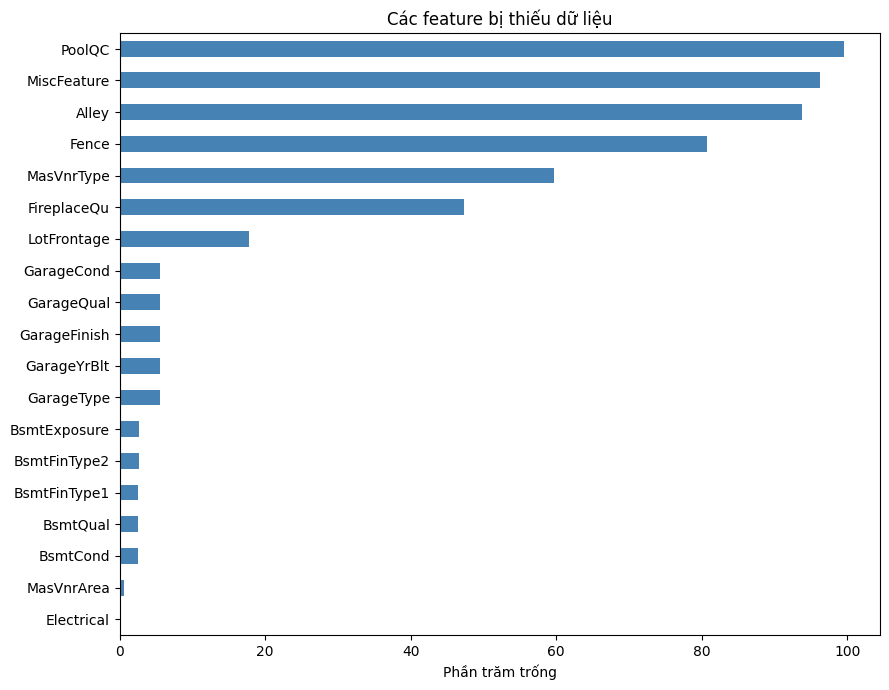

In [6]:
missing_count = train_df.isna().sum()
missing_table = pd.DataFrame({
    "Số ô trống": missing_count,
    "Phần trăm trống": missing_count / len(train_df) * 100,
})
missing_table = missing_table[missing_table["Số ô trống"] > 0]
missing_table = missing_table.sort_values("Số ô trống", ascending=False)

print("Có", len(missing_table), "feature bị thiếu dữ liệu trong train.csv")
display(missing_table.round(2))

ax = missing_table["Phần trăm trống"].sort_values().plot.barh(
    figsize=(9, 7), color="steelblue"
)
ax.set_title("Các feature bị thiếu dữ liệu")
ax.set_xlabel("Phần trăm trống")
plt.tight_layout()
plt.show()

## 4. Mình chọn feature bằng suy luận đơn giản

Mình đoán giá nhà thường liên quan đến chất lượng, diện tích, tuổi nhà, vị trí và garage. Vì vậy mình chọn 11 feature gốc dưới đây, thay vì đưa cả 79 feature vào rồi không giải thích nổi.

- OverallQual: chất lượng tổng thể cao thì nhà có lẽ đắt hơn.
- GrLivArea, LotArea và LotFrontage: nhà hoặc đất rộng thường có giá cao hơn.
- GarageCars: garage chứa được nhiều xe có vẻ là một điểm cộng.
- Fireplaces: lò sưởi có thể đại diện cho tiện nghi.
- MasVnrArea: diện tích ốp đá có thể liên quan đến độ hoàn thiện.
- Neighborhood: vị trí thường ảnh hưởng mạnh đến giá nhà.
- HouseStyle: kiểu nhà khác nhau có thể có giá khác nhau.
- KitchenQual: bếp tốt có thể làm nhà hấp dẫn hơn.
- GarageType: loại garage có thể cho biết garage tốt hay chỉ là chỗ để xe đơn giản.

Mình còn tự ghép thêm bốn feature: tổng diện tích, tổng số phòng tắm, tuổi nhà lúc bán và số năm từ lần sửa gần nhất. Đây là phỏng đoán chủ quan, không phải kết quả của một cuộc thử nghiệm chọn feature.

## 5. Chia 80% train và 20% kiểm tra

Mình chia dữ liệu trước khi tính mean hoặc mode. Như vậy 20% kiểm tra không lén nói đáp án cho phần xử lý dữ liệu.

In [7]:
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(train_df))
split_position = int(0.80 * len(train_df))

train_indices = indices[:split_position]
holdout_indices = indices[split_position:]

train_part = train_df.iloc[train_indices].copy()
holdout_part = train_df.iloc[holdout_indices].copy()
kaggle_test_part = test_df.copy()

y_train = train_part["SalePrice"].to_numpy(dtype=float)
y_holdout = holdout_part["SalePrice"].to_numpy(dtype=float)

print("80% để học      :", len(train_part), "căn nhà")
print("20% để kiểm tra :", len(holdout_part), "căn nhà")
print("Kaggle test.csv :", len(kaggle_test_part), "căn nhà")

80% để học      : 1168 căn nhà
20% để kiểm tra : 292 căn nhà
Kaggle test.csv : 1459 căn nhà


## 6. Tạo bốn feature mới

Các phép cộng dưới đây chỉ dùng thông tin của chính căn nhà đó. Nếu một phần basement hoặc phòng tắm bị thiếu, mình tạm xem phần đó bằng 0.

In [8]:
ORIGINAL_FEATURES = [
    "OverallQual", "GrLivArea", "GarageCars", "LotArea",
    "LotFrontage", "Fireplaces", "MasVnrArea",
    "Neighborhood", "HouseStyle", "KitchenQual", "GarageType",
]

ENGINEERED_FEATURES = [
    "TotalSF", "TotalBathrooms", "HouseAgeAtSale", "YearsSinceRemodel",
]

FINAL_FEATURES = ORIGINAL_FEATURES + ENGINEERED_FEATURES
CATEGORICAL_FEATURES = [
    "Neighborhood", "HouseStyle", "KitchenQual", "GarageType",
]

def make_features(df):
    result = df.copy()
    result["TotalSF"] = (
        result["TotalBsmtSF"].fillna(0)
        + result["1stFlrSF"].fillna(0)
        + result["2ndFlrSF"].fillna(0)
    )
    result["TotalBathrooms"] = (
        result["FullBath"].fillna(0)
        + 0.5 * result["HalfBath"].fillna(0)
        + result["BsmtFullBath"].fillna(0)
        + 0.5 * result["BsmtHalfBath"].fillna(0)
    )
    result["HouseAgeAtSale"] = result["YrSold"] - result["YearBuilt"]
    result["YearsSinceRemodel"] = result["YrSold"] - result["YearRemodAdd"]
    return result[FINAL_FEATURES]

train_features_raw = make_features(train_part)
holdout_features_raw = make_features(holdout_part)
kaggle_features_raw = make_features(kaggle_test_part)

print("Số feature mình chọn:", len(FINAL_FEATURES))
display(train_features_raw.head())

Số feature mình chọn: 15


,OverallQual,GrLivArea,GarageCars,LotArea,LotFrontage,Fireplaces,MasVnrArea,Neighborhood,HouseStyle,KitchenQual,GarageType,TotalSF,TotalBathrooms,HouseAgeAtSale,YearsSinceRemodel
1257,5,864,0,4060,56.0,0,0.0,Edwards,1Story,TA,NaN,1728,1.0,87,59
612,8,1872,2,11885,NaN,1,108.0,CollgCr,2Story,Ex,BuiltIn,3171,3.5,8,8
1270,7,1524,2,23595,NaN,1,0.0,ClearCr,1Story,Gd,Attchd,2856,2.5,31,31
1061,3,894,3,18000,120.0,0,0.0,IDOTRR,1Story,TA,Detchd,1788,1.0,73,58
184,5,1252,2,7438,92.0,0,0.0,BrkSide,1.5Fin,TA,Attchd,1756,1.0,98,15


## 7. Điền dữ liệu thiếu cho 15 feature đã chọn

Cách suy luận của mình:

- MasVnrArea thiếu thì xem như không có phần ốp đá và điền 0.
- GarageCars thiếu thì xem như không có chỗ để xe và điền 0.
- GarageType thiếu thì điền None, nghĩa là không có garage.
- LotFrontage là một số đo thật, nên mình điền mean của 80% train.
- Nếu sau này một feature số khác bị thiếu, dùng mean; categorical khác bị thiếu, dùng mode của 80% train.

Đây chỉ là các giả định đơn giản đầu tiên của mình. Chúng có thể chưa phải lựa chọn tối ưu.

In [27]:
ZERO_NUMERIC_FEATURES = {"GarageCars", "MasVnrArea"}
NONE_CATEGORICAL_FEATURES = {"GarageType"}
NUMERIC_FEATURES = [
    column for column in FINAL_FEATURES
    if column not in CATEGORICAL_FEATURES
]

# Chỉ học giá trị điền từ 80% train.
numeric_fill_values = {}
for column in NUMERIC_FEATURES:
    if column in ZERO_NUMERIC_FEATURES:
        numeric_fill_values[column] = 0.0
    else:
        numeric_fill_values[column] = float(train_features_raw[column].mean())

categorical_fill_values = {}
for column in CATEGORICAL_FEATURES:
    if column in NONE_CATEGORICAL_FEATURES:
        categorical_fill_values[column] = "None"
    else:
        categorical_fill_values[column] = str(
            train_features_raw[column].mode().iloc[0]
        )

fill_rules = pd.DataFrame({
    "Feature": list(numeric_fill_values) + list(categorical_fill_values),
    "Giá trị dùng để điền": (
        list(numeric_fill_values.values())
        + list(categorical_fill_values.values())
    ),
})
display(fill_rules)

,Feature,Giá trị dùng để điền
0,OverallQual,6.121575
1,GrLivArea,1516.404966
2,GarageCars,0.0
3,LotArea,10094.516267
4,LotFrontage,70.115866
5,Fireplaces,0.616438
6,MasVnrArea,0.0
7,TotalSF,2570.277397
8,TotalBathrooms,2.217466
9,HouseAgeAtSale,36.342466


In [11]:
def fill_missing_values(df):
    result = df.copy()
    for column, value in numeric_fill_values.items():
        result[column] = pd.to_numeric(
            result[column], errors="coerce"
        ).fillna(value)
    for column, value in categorical_fill_values.items():
        result[column] = (
            result[column].astype("string").fillna(value).astype(str)
        )
    return result

train_features = fill_missing_values(train_features_raw)
holdout_features = fill_missing_values(holdout_features_raw)
kaggle_features = fill_missing_values(kaggle_features_raw)

assert not train_features.isna().any().any()
assert not holdout_features.isna().any().any()
assert not kaggle_features.isna().any().any()

print("Ô trống còn lại ở 80% train :", train_features.isna().sum().sum())
print("Ô trống còn lại ở 20% test  :", holdout_features.isna().sum().sum())
print("Ô trống còn lại ở test.csv  :", kaggle_features.isna().sum().sum())

Ô trống còn lại ở 80% train : 0
Ô trống còn lại ở 20% test  : 0
Ô trống còn lại ở test.csv  : 0


## 8. Đổi categorical feature thành các cột 0 và 1

Hồi quy tuyến tính chỉ nhân được với số. pandas.get_dummies sẽ biến từng lựa chọn như Neighborhood thành nhiều công tắc 0/1.

Danh sách cột được lấy từ 80% train. Hai tập còn lại chỉ được sắp theo danh sách đó.

In [12]:
X_train_table = pd.get_dummies(
    train_features, columns=CATEGORICAL_FEATURES, dtype=float
)
ENCODED_COLUMNS = X_train_table.columns.tolist()

def encode_like_train(df):
    encoded = pd.get_dummies(
        df, columns=CATEGORICAL_FEATURES, dtype=float
    )
    return encoded.reindex(columns=ENCODED_COLUMNS, fill_value=0.0)

X_holdout_table = encode_like_train(holdout_features)
X_kaggle_table = encode_like_train(kaggle_features)

assert X_train_table.columns.equals(X_holdout_table.columns)
assert X_train_table.columns.equals(X_kaggle_table.columns)

print("Trước one-hot:", len(FINAL_FEATURES), "feature")
print("Sau one-hot  :", X_train_table.shape[1], "cột số")
display(X_train_table.head())

Trước one-hot: 15 feature
Sau one-hot  : 55 cột số


,OverallQual,GrLivArea,GarageCars,LotArea,LotFrontage,Fireplaces,MasVnrArea,TotalSF,TotalBathrooms,HouseAgeAtSale,YearsSinceRemodel,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
1257,5,864,0,4060,56.000000,0,0.0,1728,1.0,87,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
612,8,1872,2,11885,70.115866,1,108.0,3171,3.5,8,8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1270,7,1524,2,23595,70.115866,1,0.0,2856,2.5,31,31,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1061,3,894,3,18000,120.000000,0,0.0,1788,1.0,73,58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
184,5,1252,2,7438,92.000000,0,0.0,1756,1.0,98,15,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 9. Chuẩn hóa feature

LotArea có thể lớn hàng chục nghìn, trong khi GarageCars chỉ khoảng 0 đến 4. Nếu giữ nguyên, gradient của các feature có thang đo lớn dễ lấn át phần còn lại.

Mình đưa mỗi cột về gần mean 0 và độ lệch chuẩn 1. Mean và std vẫn chỉ được tính từ 80% train.

In [14]:
def fit_standardizer(X_train):
    X_train = np.asarray(X_train, dtype=float)
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    return mean, std

def transform(X, mean, std):
    X = np.asarray(X, dtype=float)
    safe_std = np.where(std == 0, 1.0, std)
    result = (X - mean) / safe_std
    result[:, std == 0] = 0.0
    return result

X_train_raw = X_train_table.to_numpy(dtype=float)
X_holdout_raw = X_holdout_table.to_numpy(dtype=float)
X_kaggle_raw = X_kaggle_table.to_numpy(dtype=float)

feature_mean, feature_std = fit_standardizer(X_train_raw)
X_train = transform(X_train_raw, feature_mean, feature_std)
X_holdout = transform(X_holdout_raw, feature_mean, feature_std)
X_kaggle = transform(X_kaggle_raw, feature_mean, feature_std)

assert X_train.shape[1] == X_holdout.shape[1] == X_kaggle.shape[1]
assert np.isfinite(X_train).all()
assert np.isfinite(X_holdout).all()
assert np.isfinite(X_kaggle).all()

print("X_train shape  :", X_train.shape)
print("X_holdout shape:", X_holdout.shape)
print("X_kaggle shape :", X_kaggle.shape)
print("Mean vài cột đầu sau chuẩn hóa:", X_train.mean(axis=0)[:5].round(4))

X_train shape  : (1168, 55)
X_holdout shape: (292, 55)
X_kaggle shape : (1459, 55)
Mean vài cột đầu sau chuẩn hóa: [-0. -0.  0. -0. -0.]


## 10. Tự viết hồi quy tuyến tính bằng NumPy

Mô hình dự đoán theo công thức:

y_pred = X @ w + b

Ban đầu mọi weight và bias đều bằng 0. Mỗi epoch, mình tính sai số, gradient rồi dịch w và b một bước nhỏ theo hướng làm loss giảm.

In [15]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return float(mae), float(mse), float(rmse), float(r2)


class LinearRegressionGD:
    def __init__(self, learning_rate=0.003, epochs=5000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y, print_every=250):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        m, n = X.shape

        self.w_ = np.zeros(n, dtype=float)
        self.b_ = 0.0
        self.loss_history_ = []

        initial_error = X @ self.w_ + self.b_ - y
        initial_loss = np.mean(initial_error ** 2) / 2.0
        self.loss_history_.append(float(initial_loss))
        print(f"Epoch {0:4d}/{self.epochs} | loss = {initial_loss:,.2f}")

        for epoch in range(1, self.epochs + 1):
            y_pred = X @ self.w_ + self.b_
            error = y_pred - y

            dw = X.T @ error / m
            db = np.mean(error)

            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db

            new_error = X @ self.w_ + self.b_ - y
            loss = np.mean(new_error ** 2) / 2.0
            self.loss_history_.append(float(loss))

            if epoch % print_every == 0 or epoch == self.epochs:
                print(f"Epoch {epoch:4d}/{self.epochs} | loss = {loss:,.2f}")

        self.loss_history_ = np.asarray(self.loss_history_)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

## 11. Bấm cell này để nhìn mô hình train

Epoch là số lần mô hình nhìn qua toàn bộ 80% train. Loss ở đây là MSE chia 2 nên số khá lớn vì mình đang học trực tiếp giá nhà theo USD.

In [20]:
model = LinearRegressionGD(learning_rate=0.001, epochs=30000)
model.fit(X_train, y_train, print_every=250)

assert np.isfinite(model.loss_history_).all()
assert model.loss_history_[-1] < model.loss_history_[0]
print("\nTrain xong!")

Epoch    0/30000 | loss = 19,402,436,063.32
Epoch  250/30000 | loss = 10,608,172,650.18
Epoch  500/30000 | loss = 6,560,420,427.98
Epoch  750/30000 | loss = 4,153,633,934.36
Epoch 1000/30000 | loss = 2,699,224,562.85
Epoch 1250/30000 | loss = 1,818,326,576.98
Epoch 1500/30000 | loss = 1,284,191,709.98
Epoch 1750/30000 | loss = 960,035,806.85
Epoch 2000/30000 | loss = 763,144,344.61
Epoch 2250/30000 | loss = 643,434,972.98
Epoch 2500/30000 | loss = 570,559,828.08
Epoch 2750/30000 | loss = 526,119,428.37
Epoch 3000/30000 | loss = 498,953,683.42
Epoch 3250/30000 | loss = 482,290,873.27
Epoch 3500/30000 | loss = 472,020,376.36
Epoch 3750/30000 | loss = 465,645,751.28
Epoch 4000/30000 | loss = 461,649,984.73
Epoch 4250/30000 | loss = 459,110,538.36
Epoch 4500/30000 | loss = 457,465,834.18
Epoch 4750/30000 | loss = 456,373,569.40
Epoch 5000/30000 | loss = 455,624,725.90
Epoch 5250/30000 | loss = 455,091,364.91
Epoch 5500/30000 | loss = 454,694,920.32
Epoch 5750/30000 | loss = 454,386,932.26


## 12. Mảng trọng số mô hình học được

Mỗi cột sau one-hot có một weight. Vì feature đã được chuẩn hóa, weight dương lớn thường đẩy dự đoán lên và weight âm lớn thường kéo dự đoán xuống. Đây chỉ là cách mô hình đang sử dụng feature, không chứng minh nguyên nhân thật ngoài đời.

In [21]:
print("Bias:", round(model.b_, 2))
print("Mảng weights đầy đủ:")
print(model.w_)

weight_table = pd.DataFrame({
    "Feature sau one-hot": ENCODED_COLUMNS,
    "Weight": model.w_,
})
weight_table["Độ lớn"] = weight_table["Weight"].abs()
weight_table = weight_table.sort_values("Độ lớn", ascending=False)

print("\n20 weight có độ lớn cao nhất:")
display(weight_table.head(20).drop(columns="Độ lớn"))

Bias: 181061.73
Mảng weights đầy đủ:
[17755.29  19137.261 10139.15   4616.146 -1832.37   3272.49   4602.687
  4177.695  7521.647 -1682.298 -5115.688 -2038.646  -933.228 -2238.989
   599.409  1208.252   117.738  3923.799 -3296.776 -1319.285 -1506.045
 -1949.16  -1298.56  -1805.135 -1449.254 -3151.899  6843.411  8222.576
 -3879.867 -1719.162 -1118.943  -386.756  2440.277  4917.917   549.736
  1746.422  -231.312   581.437  3603.698  -179.288   -66.369 -4263.056
   853.406   325.429  9493.703 -1193.015 -1569.411 -2851.323 -3186.771
   772.162  -491.243  1672.855 -1784.55  -1649.446  1734.379]

20 weight có độ lớn cao nhất:


,Feature sau one-hot,Weight
1,GrLivArea,19137.260762
0,OverallQual,17755.290305
2,GarageCars,10139.150305
44,KitchenQual_Ex,9493.702801
27,Neighborhood_NridgHt,8222.576213
8,TotalBathrooms,7521.646891
26,Neighborhood_NoRidge,6843.411111
10,YearsSinceRemodel,-5115.687556
33,Neighborhood_StoneBr,4917.917166
3,LotArea,4616.145943


## 13. Đánh giá trên 20% dữ liệu mô hình chưa học

Baseline đơn giản nhất là luôn đoán bằng giá trung bình của 80% train. Mô hình của mình nên có RMSE thấp hơn baseline này.

In [25]:
holdout_prediction = model.predict(X_holdout)
baseline_prediction = np.full_like(y_holdout, y_train.mean())

baseline_mae, baseline_mse, baseline_rmse, baseline_r2 = regression_metrics(
    y_holdout, baseline_prediction
)
model_mae, model_mse, model_rmse, model_r2 = regression_metrics(
    y_holdout, holdout_prediction
)

metric_table = pd.DataFrame([
    {
        "Mô hình": "Đoán bằng mean",
        "MAE": baseline_mae,
        "MSE": baseline_mse,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
    },
    {
        "Mô hình": "Linear Regression NumPy",
        "MAE": model_mae,
        "MSE": model_mse,
        "RMSE": model_rmse,
        "R2": model_r2,
    },
])

display(metric_table.round({"MAE": 2, "MSE": 2, "RMSE": 2, "R2": 4}))
assert model_rmse < baseline_rmse

,Mô hình,MAE,MSE,RMSE,R2
0,Đoán bằng mean,59493.43,7.447951e+09,86301.51,-0.0001
1,Linear Regression NumPy,22320.92,1.455733e+09,38154.07,0.8045


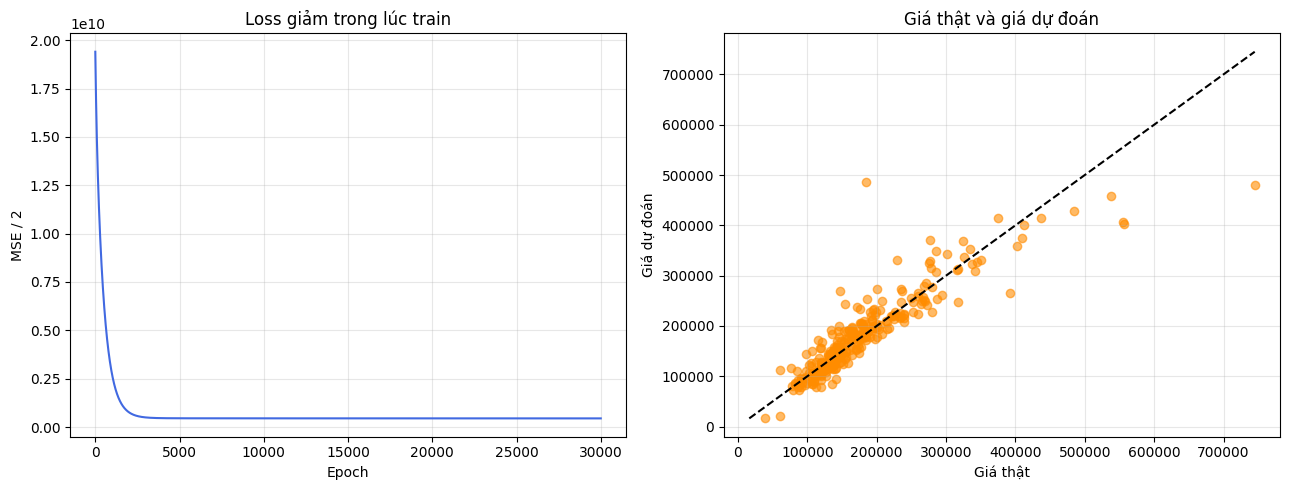

,Giá thật,Giá dự đoán,Sai lệch
0,180000.0,175385.39,-4614.61
1,239799.0,222891.47,-16907.53
2,107000.0,106853.46,-146.54
3,76000.0,116475.31,40475.31
4,165000.0,179906.77,14906.77
5,173000.0,162717.56,-10282.44
6,145000.0,199742.23,54742.23
7,115000.0,172612.23,57612.23
8,177500.0,180484.10,2984.10
9,132500.0,131670.92,-829.08


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(model.loss_history_, color="royalblue")
axes[0].set_title("Loss giảm trong lúc train")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE / 2")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_holdout, holdout_prediction, alpha=0.6, color="darkorange")
low = min(y_holdout.min(), holdout_prediction.min())
high = max(y_holdout.max(), holdout_prediction.max())
axes[1].plot([low, high], [low, high], "--", color="black")
axes[1].set_title("Giá thật và giá dự đoán")
axes[1].set_xlabel("Giá thật")
axes[1].set_ylabel("Giá dự đoán")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Giá thật": y_holdout[:10],
    "Giá dự đoán": holdout_prediction[:10],
    "Sai lệch": holdout_prediction[:10] - y_holdout[:10],
})
display(comparison.round(2))

## 14. Dự đoán test.csv và tạo submission

Theo mục tiêu ban đầu, mình dùng nguyên mô hình đã học từ 80% train. Mình không fit lại bằng 100% dữ liệu.

Vì giá nhà không thể âm, dự đoán âm sẽ được chặn về 0 trước khi ghi file.

In [24]:
kaggle_prediction = model.predict(X_kaggle)
kaggle_prediction = np.maximum(kaggle_prediction, 0.0)

submission = pd.DataFrame({
    "Id": test_df["Id"].to_numpy(),
    "SalePrice": kaggle_prediction,
})

assert len(submission) == len(test_df)
assert submission.columns.tolist() == ["Id", "SalePrice"]
assert submission["SalePrice"].notna().all()
assert (submission["SalePrice"] >= 0).all()
if sample_submission is not None:
    assert submission["Id"].equals(sample_submission["Id"])

default_output_dir = DATA_DIR.parent if DATA_DIR.name == "data" else Path.cwd()
OUTPUT_DIR = Path(os.environ.get("HOUSE_PRICE_OUTPUT_DIR", default_output_dir))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = OUTPUT_DIR / "submission_beginner.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print("Đã tạo:", SUBMISSION_PATH.resolve())
print("Số dòng:", len(submission))
display(submission.head())

try:
    from google.colab import files
    files.download(str(SUBMISSION_PATH))
except ImportError:
    print("Không chạy trên Colab nên không tự tải file xuống.")

Đã tạo: /content/submission_beginner.csv
Số dòng: 1459


,Id,SalePrice
0,1461,103498.083636
1,1462,148404.474243
2,1463,164384.968555
3,1464,175655.410090
4,1465,237842.909037


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Điều mình rút ra

- Dữ liệu thực tế có nhiều ô trống và không phải ô trống nào cũng mang cùng một ý nghĩa.
- Categorical feature phải đổi thành số trước khi đưa vào hồi quy tuyến tính.
- Chuẩn hóa giúp gradient descent học dễ hơn khi các feature có đơn vị rất khác nhau.
- Loss giảm trên train chưa đủ; mình vẫn cần 20% chưa dùng để học nhằm đánh giá.
- Mô hình này còn đơn giản và các quyết định feature engineering chủ yếu dựa trên trực giác. Đó là điểm bắt đầu để mình hiểu quy trình trước khi học các cách làm phức tạp hơn.